# Forecast Request Client

This notebook acts as a **client** for requesting forecasts from the ML server.

## How it works:

1. **Model lookup priority** (automatic on server):
   - First check local cache: `/tmp/local_models_cache/<model_id>/<alias>/<version>/bundle`
   - If not found → fetch from MLflow Registry
   - Cache is populated on first request and reused for subsequent requests

2. **Workflow:**
   - (Optional) Run Cell 3 to see available models
   - (Optional) Run Cells 5-7 to preload models into cache before forecasting
   - Configure your parameters in Cell 2
   - Run Cell 8 to request forecast
   - (Optional) Run Cells 9-10 to see curl commands for manual data download
   - View results in Cells 11-12 (visualization & statistics)

## What you need to provide:

- `PREDICT_URL`: API endpoint (usually `http://localhost:8030/predict`)
- `PREDICT_MODEL_ID`: Model identifier (from Cell 4 or custom)
- `PREDICT_CLIENT_OBJECT_REF`: Data reference path (the time series identifier)
- (Optional) `PREDICT_MODEL_SELECTION`: Model version alias (default: `Production`)

## Cache behavior:

✓ Models in cache are used immediately (fast)  
✓ Models not in cache are fetched from MLflow on demand  
✓ Cache persists across requests  
✓ Fallback: if MLflow unavailable, uses latest cached version  

## Preloading models (optional):

You can explicitly preload models into cache before running forecasts:
- Use Cell 5 to see available models
- Use Cells 6-7 to preload models via MLflow
- Preloaded models are ready for instant use

In [19]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import requests

# ============================================================================
# USER CONFIGURATION - Modify these values for your forecast request
# ============================================================================
# 📝 Server-side model resolution (automatic):
#    1. Check cache: /tmp/local_models_cache/<model_id>/<version_alias>/...
#    2. If not cached → fetch from MLflow Registry
#    3. Store in cache for future requests
#
# 💡 Tip: Run Cell 3 below to discover available models

# API server endpoint
PREDICT_URL = "http://127.0.0.1:8030/predict"

# Model ID (example models):
# - root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt
# - root_FP_PROJECT_AKMOLA_regions_Kokshetau_load_models_P_watt
# - root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt
# (See Cell 3 for available models)
# PREDICT_MODEL_ID = "root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt"
PREDICT_MODEL_ID = "root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model"

# Data reference (time series identifier)
# Example: /root/FP/PROJECT/AKMOLA/@regions/KOKSHETAU/Load/P_load/archives/out_value
PREDICT_CLIENT_OBJECT_REF = "/root/FP/PROJECT/AKMOLA/@regions/North Kazakhstan/load/@models/P_watt"

# Model version/alias (optional)
# Server looks for this alias in model registry, default is "Production"
PREDICT_MODEL_SELECTION = {"version_alias": "Production"}

# Polling configuration
PREDICT_MAX_ATTEMPTS = 30
PREDICT_POLL_INTERVAL = 1.0

# Derived URLs
TASKS_URL_BASE = PREDICT_URL.rsplit("/predict", 1)[0] + "/tasks"

print("=" * 70)
print("CLIENT CONFIGURATION")
print("=" * 70)
print(f"API Endpoint: {PREDICT_URL}")
print(f"Model ID: {PREDICT_MODEL_ID}")
print(f"Object Reference: {PREDICT_CLIENT_OBJECT_REF}")
print(f"Model Selection: {PREDICT_MODEL_SELECTION}")
print(f"Tasks Polling URL: {TASKS_URL_BASE}")
print("\n📍 Resolution strategy: Cache first → MLflow fallback")
print("=" * 70)

CLIENT CONFIGURATION
API Endpoint: http://127.0.0.1:8030/predict
Model ID: root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model
Object Reference: /root/FP/PROJECT/AKMOLA/@regions/North Kazakhstan/load/@models/P_watt
Model Selection: {'version_alias': 'Production'}
Tasks Polling URL: http://127.0.0.1:8030/tasks

📍 Resolution strategy: Cache first → MLflow fallback


### CHECK LOCAL CACHE - List available models in /tmp/local_models_cache

This cell shows which models are already cached locally (no MLflow needed)
Models not in cache will be fetched from MLflow on demand

In [20]:
import os
from pathlib import Path

# ============================================================================
# CHECK LOCAL CACHE - List available models in /tmp/local_models_cache
# ============================================================================
# This cell shows which models are already cached locally (no MLflow needed)
# Models not in cache will be fetched from MLflow on demand

CACHE_DIR = Path("/tmp/local_models_cache")

print("=" * 70)
print("LOCAL MODEL CACHE CHECK")
print("=" * 70)

if CACHE_DIR.exists():
    cached_models = sorted([d.name for d in CACHE_DIR.iterdir() if d.is_dir()])
    if cached_models:
        print(f"✓ Cache directory exists: {CACHE_DIR}")
        print(f"✓ Cached models ({len(cached_models)}):")
        for model in cached_models:
            model_path = CACHE_DIR / model
            versions = sorted([d.name for d in model_path.iterdir() if d.is_dir()])
            if versions:
                print(f"  - {model}")
                for version in versions:
                    version_path = model_path / version
                    bundle_path = version_path / "bundle" / "configuration" / "cache_config.json"
                    status = "✓" if bundle_path.exists() else "✗"
                    print(f"    {status} {version}/")
    else:
        print(f"ℹ Cache exists but is empty: {CACHE_DIR}")
        print("  Models will be fetched from MLflow on demand")
else:
    print(f"ℹ Cache directory not found: {CACHE_DIR}")
    print("  Models will be fetched from MLflow on demand")
    print("  Cache will be created on first request")

print("\n📝 Current selection: PREDICT_MODEL_ID = " + PREDICT_MODEL_ID)
print("=" * 70)


LOCAL MODEL CACHE CHECK
ℹ Cache exists but is empty: /tmp/local_models_cache
  Models will be fetched from MLflow on demand

📝 Current selection: PREDICT_MODEL_ID = root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model



### DISCOVER AVAILABLE MODELS (optional helper)

Shows all available models from cache and mlruns
Use this to select a model_id for your forecast

In [21]:
# ============================================================================
# DISCOVER AVAILABLE MODELS (optional helper)
# ============================================================================
# Shows all available models from cache and mlruns
# Use this to select a model_id for your forecast

import os
from pathlib import Path

def discover_models():
    """Find all available models from cache and mlruns."""
    models = {}
    
    # Check cache
    cache_dir = Path("/tmp/local_models_cache")
    if cache_dir.exists():
        for model_dir in cache_dir.iterdir():
            if model_dir.is_dir():
                model_id = model_dir.name
                versions = []
                for version_dir in model_dir.iterdir():
                    if version_dir.is_dir():
                        versions.append(version_dir.name)
                models[model_id] = {"source": "cache", "versions": versions}
    
    return models

available_models = discover_models()

print("=" * 70)
print("AVAILABLE MODELS FOR SELECTION")
print("=" * 70)

if available_models:
    for i, (model_id, info) in enumerate(available_models.items(), 1):
        source = info["source"]
        print(f"{i}. {model_id}")
        print(f"   Source: {source}")
        print(f"   Versions/Runs: {len(info['versions'])}")
else:
    print("No models found in cache or mlruns.")
    print("Models will be fetched from MLflow on demand.")

print("\n💡 TIP: Copy a model_id from above and paste into Cell 2 (PREDICT_MODEL_ID)")
print("=" * 70)


AVAILABLE MODELS FOR SELECTION
No models found in cache or mlruns.
Models will be fetched from MLflow on demand.

💡 TIP: Copy a model_id from above and paste into Cell 2 (PREDICT_MODEL_ID)


### PRELOAD MODEL INTO CACHE (optional)

Use this cell to explicitly download a model from MLflow into local cache
Useful if you know you'll need a specific model but haven't run a forecast yet

In [22]:
# ============================================================================
# PRELOAD MODEL INTO CACHE (optional)
# ============================================================================
# Use this cell to explicitly download a model from MLflow into local cache.
# Useful if you know you'll need a specific model but haven't run a forecast yet.

import os
from pathlib import Path
from tempfile import TemporaryDirectory

try:
    from mlflow.tracking import MlflowClient
    from shutil import move, rmtree
except ImportError:
    print("MLflow not installed. Skipping preload functionality.")
    MlflowClient = None


def _discover_bundle_candidates(client: Any, run_id: str, max_depth: int = 5) -> tuple[list[str], bool]:
    """Return (bundle_dir_candidates, root_has_configuration_dir)."""
    stack: list[tuple[str, int]] = [("", 0)]
    seen: set[str] = set()
    all_dirs: set[str] = set()

    while stack:
        current_path, depth = stack.pop()
        if depth > max_depth:
            continue

        try:
            entries = client.list_artifacts(run_id, current_path)
        except Exception:
            continue

        for entry in entries:
            entry_path = entry.path
            if entry.is_dir and entry_path not in seen:
                seen.add(entry_path)
                all_dirs.add(entry_path)
                stack.append((entry_path, depth + 1))

    bundle_dirs = sorted([p for p in all_dirs if Path(p).name == "bundle"], key=len)
    root_has_configuration = "configuration" in all_dirs
    return bundle_dirs, root_has_configuration


def _stage_bundle_from_candidate(client: Any, run_id: str, target_bundle: Path, artifact_path: str) -> None:
    """Download artifact path and normalize it into target bundle directory."""
    if target_bundle.exists():
        rmtree(target_bundle)

    if artifact_path != "__ROOT_CONFIGURATION__":
        local_path = Path(client.download_artifacts(run_id, artifact_path))
        move(str(local_path), str(target_bundle))
        return

    with TemporaryDirectory() as tmp_dir:
        tmp_path = Path(tmp_dir)
        staged_bundle = tmp_path / "bundle"
        staged_bundle.mkdir(parents=True, exist_ok=True)

        for sub_path in ("configuration", "model", "assets"):
            try:
                local_sub = Path(client.download_artifacts(run_id, sub_path, tmp_dir))
            except Exception:
                continue
            if local_sub.exists() and local_sub.is_dir():
                move(str(local_sub), str(staged_bundle / sub_path))

        move(str(staged_bundle), str(target_bundle))


def preload_model_to_cache(model_id: str, version_alias: str = "Production") -> dict[str, Any]:
    """
    Preload a model from MLflow into local cache.

    Args:
        model_id: Model identifier
        version_alias: Model version alias (default: Production)

    Returns:
        Status dict with success flag and diagnostics
    """
    if not MlflowClient:
        return {
            "success": False,
            "message": "MLflow not available",
            "model_id": model_id,
            "alias": version_alias,
        }

    try:
        tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5050")
        registry_uri = os.getenv("MLFLOW_REGISTRY_URI", tracking_uri)
        client = MlflowClient(tracking_uri=tracking_uri, registry_uri=registry_uri)

        model_version_obj = None
        try:
            model_version_obj = client.get_model_version_by_alias(model_id, version_alias)
        except Exception:
            model = client.get_registered_model(model_id)
            matching_versions = [v for v in model.latest_versions if v.current_stage == version_alias]
            if not matching_versions:
                matching_versions = list(model.latest_versions)
            if not matching_versions:
                return {
                    "success": False,
                    "message": f"No version found with alias: {version_alias}",
                    "model_id": model_id,
                    "alias": version_alias,
                    "tracking_uri": tracking_uri,
                    "registry_uri": registry_uri,
                }
            model_version_obj = matching_versions[0]

        run_id = model_version_obj.run_id
        model_version = str(model_version_obj.version)

        cache_path = Path(f"/tmp/local_models_cache/{model_id}/{version_alias}/{model_version}")
        cache_path.mkdir(parents=True, exist_ok=True)
        target_bundle = cache_path / "bundle"

        candidate_paths: list[str] = ["bundle"]
        discovered_bundle_dirs, root_has_configuration = _discover_bundle_candidates(client, run_id)
        for path in discovered_bundle_dirs:
            if path not in candidate_paths:
                candidate_paths.append(path)
        if root_has_configuration:
            candidate_paths.append("__ROOT_CONFIGURATION__")

        errors: list[str] = []
        for artifact_path in candidate_paths:
            try:
                _stage_bundle_from_candidate(client, run_id, target_bundle, artifact_path)

                config_path = target_bundle / "configuration" / "cache_config.json"
                if config_path.exists():
                    return {
                        "success": True,
                        "message": "Model preloaded successfully",
                        "model_id": model_id,
                        "alias": version_alias,
                        "model_version": model_version,
                        "run_id": run_id,
                        "artifact_path": artifact_path,
                        "cache_path": str(cache_path),
                        "config_path": str(config_path),
                        "tracking_uri": tracking_uri,
                        "registry_uri": registry_uri,
                        "tried_artifact_paths": candidate_paths,
                    }

                errors.append(f"{artifact_path}: configuration/cache_config.json not found")
                if target_bundle.exists():
                    rmtree(target_bundle)
            except Exception as exc:
                errors.append(f"{artifact_path}: {exc}")

        return {
            "success": False,
            "message": "No valid bundle artifact path found",
            "model_id": model_id,
            "alias": version_alias,
            "model_version": model_version,
            "run_id": run_id,
            "cache_path": str(cache_path),
            "tracking_uri": tracking_uri,
            "registry_uri": registry_uri,
            "tried_artifact_paths": candidate_paths,
            "errors": errors,
        }

    except Exception as e:
        return {
            "success": False,
            "message": f"Error: {str(e)}",
            "model_id": model_id,
            "alias": version_alias,
            "tracking_uri": os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5050"),
            "registry_uri": os.getenv("MLFLOW_REGISTRY_URI", os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5050")),
        }


# Example: preload the currently selected model
print("=" * 70)
print("PRELOAD MODEL INTO CACHE")
print("=" * 70)
print(f"Model to preload: {PREDICT_MODEL_ID}")
print(f"Alias: {PREDICT_MODEL_SELECTION.get('version_alias', 'Production')}")
print()
print("To preload, run this code:")
print(f"result = preload_model_to_cache('{PREDICT_MODEL_ID}', '{PREDICT_MODEL_SELECTION.get('version_alias', 'Production')}')")
print("print(json.dumps(result, indent=2))")
print()
print("Or preload a different model:")
print("result = preload_model_to_cache('model_id_here', 'Production')")
print("=" * 70)

PRELOAD MODEL INTO CACHE
Model to preload: root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model
Alias: Production

To preload, run this code:
result = preload_model_to_cache('root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model', 'Production')
print(json.dumps(result, indent=2))

Or preload a different model:
result = preload_model_to_cache('model_id_here', 'Production')


In [23]:
# Execute preload for the currently selected model
preload_result = preload_model_to_cache(
    PREDICT_MODEL_ID,
    PREDICT_MODEL_SELECTION.get("version_alias", "Production"),
)
print(json.dumps(preload_result, ensure_ascii=True, indent=2))

{
  "success": true,
  "message": "Model preloaded successfully",
  "model_id": "root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model",
  "alias": "Production",
  "model_version": "2",
  "run_id": "352a0c3c3851429786d2df304db0f7ae",
  "artifact_path": "bundle",
  "cache_path": "/tmp/local_models_cache/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model/Production/2",
  "config_path": "/tmp/local_models_cache/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model/Production/2/bundle/configuration/cache_config.json",
  "tracking_uri": "http://127.0.0.1:5050",
  "registry_uri": "http://127.0.0.1:5050",
  "tried_artifact_paths": [
    "bundle"
  ]
}


In [24]:
import os
from pathlib import Path
from tempfile import TemporaryDirectory


@dataclass
class PredictRunResult:
    task_id: str
    start_response: dict[str, Any]
    poll_history: list[dict[str, Any]]
    final_response: dict[str, Any]


def find_cached_bundle(model_id: str, version_alias: str = "Production") -> Path | None:
    """Return cached bundle path if present in /tmp/local_models_cache."""
    alias_dir = Path("/tmp/local_models_cache") / model_id / version_alias
    if not alias_dir.exists() or not alias_dir.is_dir():
        return None

    for version_dir in sorted([d for d in alias_dir.iterdir() if d.is_dir()], reverse=True):
        bundle_path = version_dir / "bundle"
        config_path = bundle_path / "configuration" / "cache_config.json"
        if config_path.exists():
            return bundle_path

    return None


def discover_bundle_candidates(client: Any, run_id: str, max_depth: int = 5) -> tuple[list[str], bool]:
    """
    Discover possible artifact paths that may contain a model bundle.

    Returns:
        (bundle_dir_candidates, root_looks_like_bundle)
    """
    stack: list[tuple[str, int]] = [("", 0)]
    seen: set[str] = set()
    all_dirs: set[str] = set()

    while stack:
        current_path, depth = stack.pop()
        if depth > max_depth:
            continue

        try:
            entries = client.list_artifacts(run_id, current_path)
        except Exception:
            continue

        for entry in entries:
            entry_path = entry.path
            if entry.is_dir and entry_path not in seen:
                seen.add(entry_path)
                all_dirs.add(entry_path)
                stack.append((entry_path, depth + 1))

    bundle_dirs = sorted([p for p in all_dirs if Path(p).name == "bundle"], key=len)
    root_looks_like_bundle = ("configuration" in all_dirs)

    return bundle_dirs, root_looks_like_bundle


def stage_downloaded_bundle(
    client: Any,
    run_id: str,
    target_bundle: Path,
    candidate_path: str,
) -> None:
    """Download candidate artifact path and place it as target bundle directory."""
    from shutil import move, rmtree

    if target_bundle.exists():
        rmtree(target_bundle)

    if candidate_path != "__ROOT_CONFIGURATION__":
        local_path = Path(client.download_artifacts(run_id, candidate_path))
        move(str(local_path), str(target_bundle))
        return

    # Root-style layout: configuration/ (and optionally model/) at run root.
    with TemporaryDirectory() as tmp_dir:
        tmp_path = Path(tmp_dir)
        staged_bundle = tmp_path / "bundle"
        staged_bundle.mkdir(parents=True, exist_ok=True)

        for sub_path in ("configuration", "model", "assets"):
            try:
                local_sub = Path(client.download_artifacts(run_id, sub_path, tmp_dir))
            except Exception:
                continue
            if local_sub.exists() and local_sub.is_dir():
                move(str(local_sub), str(staged_bundle / sub_path))

        move(str(staged_bundle), str(target_bundle))


def ensure_model_bundle_in_local_cache(
    model_id: str,
    version_alias: str = "Production",
) -> dict[str, Any]:
    """
    Ensure model bundle exists in local cache on this client host.

    If missing, download from MLflow and store in:
    /tmp/local_models_cache/<model_id>/<version_alias>/<model_version>/bundle
    """
    cached_bundle = find_cached_bundle(model_id, version_alias)
    if cached_bundle:
        return {
            "success": True,
            "from_cache": True,
            "model_id": model_id,
            "alias": version_alias,
            "bundle_path": str(cached_bundle),
        }

    try:
        from mlflow.tracking import MlflowClient
        from shutil import rmtree
    except Exception as exc:
        return {
            "success": False,
            "from_cache": False,
            "model_id": model_id,
            "alias": version_alias,
            "message": f"MLflow client is not available: {exc}",
        }

    try:
        tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5050")
        registry_uri = os.getenv("MLFLOW_REGISTRY_URI", tracking_uri)
        client = MlflowClient(tracking_uri=tracking_uri, registry_uri=registry_uri)

        model_version_obj = None
        try:
            model_version_obj = client.get_model_version_by_alias(model_id, version_alias)
        except Exception:
            # Fallback for registries that don't use aliases.
            model = client.get_registered_model(model_id)
            candidates = [v for v in model.latest_versions if v.current_stage == version_alias]
            if not candidates:
                candidates = list(model.latest_versions)
            if not candidates:
                return {
                    "success": False,
                    "from_cache": False,
                    "model_id": model_id,
                    "alias": version_alias,
                    "tracking_uri": tracking_uri,
                    "registry_uri": registry_uri,
                    "message": f"No versions found for model '{model_id}'",
                }
            model_version_obj = candidates[0]

        run_id = model_version_obj.run_id
        model_version = str(model_version_obj.version)

        target_root = Path("/tmp/local_models_cache") / model_id / version_alias / model_version
        target_root.mkdir(parents=True, exist_ok=True)
        target_bundle = target_root / "bundle"

        candidate_paths: list[str] = ["bundle"]
        discovered_bundle_dirs, root_has_configuration = discover_bundle_candidates(client, run_id)
        for path in discovered_bundle_dirs:
            if path not in candidate_paths:
                candidate_paths.append(path)
        if root_has_configuration:
            candidate_paths.append("__ROOT_CONFIGURATION__")

        errors: list[str] = []
        for artifact_path in candidate_paths:
            try:
                stage_downloaded_bundle(client, run_id, target_bundle, artifact_path)

                config_path = target_bundle / "configuration" / "cache_config.json"
                if config_path.exists():
                    return {
                        "success": True,
                        "from_cache": False,
                        "model_id": model_id,
                        "alias": version_alias,
                        "model_version": model_version,
                        "tracking_uri": tracking_uri,
                        "registry_uri": registry_uri,
                        "run_id": run_id,
                        "artifact_path": artifact_path,
                        "bundle_path": str(target_bundle),
                    }

                errors.append(f"{artifact_path}: configuration/cache_config.json not found after download")
                if target_bundle.exists():
                    rmtree(target_bundle)
            except Exception as exc:
                errors.append(f"{artifact_path}: {exc}")

        return {
            "success": False,
            "from_cache": False,
            "model_id": model_id,
            "alias": version_alias,
            "tracking_uri": tracking_uri,
            "registry_uri": registry_uri,
            "run_id": run_id,
            "message": "Failed to populate local cache from MLflow: no valid bundle artifact path found",
            "tried_artifact_paths": candidate_paths,
            "errors": errors,
        }

    except Exception as exc:
        return {
            "success": False,
            "from_cache": False,
            "model_id": model_id,
            "alias": version_alias,
            "tracking_uri": os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5050"),
            "registry_uri": os.getenv("MLFLOW_REGISTRY_URI", os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5050")),
            "message": f"Failed to populate local cache from MLflow: {exc}",
        }


def start_predict_task(
    predict_url: str,
    model_id: str,
    client_object_ref: str,
    model_selection: dict[str, Any] | None = None,
) -> tuple[str, dict[str, Any]]:
    """
    Send a forecast request to the server.

    Args:
        predict_url: API endpoint URL (e.g., http://localhost:8030/predict)
        model_id: Model identifier
        client_object_ref: Data reference path
        model_selection: Optional model selection (e.g., {"version_alias": "Production"})

    Returns:
        Tuple of (task_id, response_data)
    """
    payload = {
        "client_object_ref": client_object_ref,
        "model_id": model_id,
    }

    if model_selection:
        payload["model_selection"] = model_selection

    resp = requests.post(predict_url, json=payload, timeout=30)
    data = resp.json()

    task_id = data.get("task_id", "")
    if not task_id:
        raise RuntimeError(f"Failed to create task. HTTP={resp.status_code}, body={data}")

    return task_id, data


def poll_predict_task(
    tasks_url_base: str,
    task_id: str,
    max_attempts: int = 30,
    poll_interval: float = 1.0,
) -> tuple[list[dict[str, Any]], dict[str, Any]]:
    """
    Poll the server for task completion.

    Args:
        tasks_url_base: Base URL for task polling (e.g., http://localhost:8030/tasks)
        task_id: Task identifier from start_predict_task
        max_attempts: Maximum polling attempts
        poll_interval: Seconds between attempts

    Returns:
        Tuple of (poll_history, final_response)
    """
    poll_history: list[dict[str, Any]] = []

    for attempt in range(1, max_attempts + 1):
        resp = requests.get(f"{tasks_url_base}/{task_id}", timeout=30)
        data = resp.json()

        status = data.get("status")
        state = data.get("state")

        poll_history.append({
            "attempt": attempt,
            "http_status": resp.status_code,
            "status": status,
            "state": state,
            "response": data,
        })

        if status == 200:
            return poll_history, data

        if status != 202:
            return poll_history, data

        time.sleep(poll_interval)

    return poll_history, {"status": "timeout", "message": "Polling timeout"}


def run_predict_flow(
    predict_url: str = PREDICT_URL,
    model_id: str = PREDICT_MODEL_ID,
    client_object_ref: str = PREDICT_CLIENT_OBJECT_REF,
    model_selection: dict[str, Any] | None = None,
    max_attempts: int = PREDICT_MAX_ATTEMPTS,
    poll_interval: float = PREDICT_POLL_INTERVAL,
) -> PredictRunResult:
    """
    Execute full forecast request flow: ensure cache -> start -> poll -> result.
    """
    selected_alias = (model_selection or {}).get("version_alias", "Production")
    cache_status = ensure_model_bundle_in_local_cache(model_id, selected_alias)

    if not cache_status.get("success"):
        raise RuntimeError(
            "Cannot run forecast: local bundle is missing and MLflow download failed. "
            f"tracking_uri={cache_status.get('tracking_uri')} registry_uri={cache_status.get('registry_uri')} "
            f"details={cache_status.get('message', 'unknown error')}"
        )

    cache_source = "local cache" if cache_status.get("from_cache") else "MLflow download"
    print(f"Model bundle ready ({cache_source}): {cache_status.get('bundle_path')}")

    task_id, start_response = start_predict_task(
        predict_url=predict_url,
        model_id=model_id,
        client_object_ref=client_object_ref,
        model_selection=model_selection,
    )

    poll_history, final_response = poll_predict_task(
        tasks_url_base=predict_url.rsplit("/predict", 1)[0] + "/tasks",
        task_id=task_id,
        max_attempts=max_attempts,
        poll_interval=poll_interval,
    )

    return PredictRunResult(
        task_id=task_id,
        start_response=start_response,
        poll_history=poll_history,
        final_response=final_response,
    )

In [25]:
# ============================================================================
# SEND FORECAST REQUEST
# ============================================================================
# This cell sends your forecast request to the ML server and waits for results.
# The request will be processed asynchronously and polled until completion.

result = run_predict_flow(
    predict_url=PREDICT_URL,
    model_id=PREDICT_MODEL_ID,
    client_object_ref=PREDICT_CLIENT_OBJECT_REF,
    model_selection=PREDICT_MODEL_SELECTION,
    max_attempts=PREDICT_MAX_ATTEMPTS,
    poll_interval=PREDICT_POLL_INTERVAL,
)

print("\n" + "=" * 70)
print("FORECAST REQUEST RESULT")
print("=" * 70)
print(f"Task ID: {result.task_id}")
print(f"Final Status: {result.final_response.get('status')}")
print(f"Final State: {result.final_response.get('state')}")
print(f"Polling Attempts: {len(result.poll_history)}")

# Extract forecast data
data = result.final_response.get("data") or {}
forecast_output = data.get("output") or []
input_statistics = data.get("input_statistics")
output_statistics = data.get("output_statistics")

print(f"Forecast Points: {len(forecast_output)}")
print("\n--- Input Statistics ---")
print(json.dumps(input_statistics, ensure_ascii=True, indent=2))
print("\n--- Output Statistics ---")
print(json.dumps(output_statistics, ensure_ascii=True, indent=2))
print("=" * 70)

Model bundle ready (local cache): /tmp/local_models_cache/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model/Production/2/bundle

FORECAST REQUEST RESULT
Task ID: 4ae891c7e82b4ae492091dc27869f959
Final Status: 422
Final State: done
Polling Attempts: 2
Forecast Points: 0

--- Input Statistics ---
null

--- Output Statistics ---
null


Archive source: live API response from 127.0.0.1
Archive rows loaded: 23
UTC range: 2026-05-09 19:00:00+00:00 -> 2026-05-10 17:00:00+00:00
No forecast data found in final response.


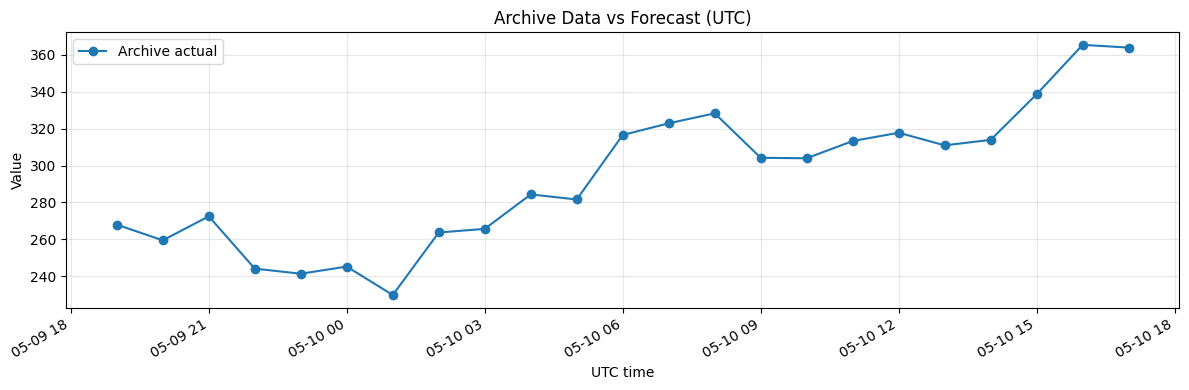

No overlapping timestamps between archive and forecast.


In [26]:
from datetime import datetime, timezone


def unix_ms_to_utc(ts_ms: int) -> datetime:
    return datetime.fromtimestamp(ts_ms / 1000, tz=timezone.utc)


def fetch_archive_series(
    read_url: str,
    archive_path: str,
    from_iso: str,
    to_iso: str,
    step_seconds: int = 3600,
) -> list[list[Any]]:
    payload = {
        "from": from_iso,
        "to": to_iso,
        "archive": [archive_path],
        "step": step_seconds,
    }
    resp = requests.post(read_url, json=payload, timeout=30)
    resp.raise_for_status()
    body = resp.json()

    if isinstance(body, dict):
        rows = body.get(archive_path) or []
        if rows:
            return rows
        # Fallback for possible single-key response where key differs from requested path.
        first_value = next(iter(body.values()), [])
        if isinstance(first_value, list):
            return first_value

    return []


def build_overlap_metrics(
    archive_rows: list[list[Any]],
    forecast_output: list[list[Any]],
) -> dict[str, Any]:
    actual_by_ts = {int(row[0]): float(row[1]) for row in archive_rows if len(row) >= 2}
    pred_by_ts = {int(row[0]): float(row[1]) for row in forecast_output if len(row) >= 2}

    common_ts = sorted(set(actual_by_ts.keys()) & set(pred_by_ts.keys()))
    if not common_ts:
        return {
            "count": 0,
            "mae": None,
            "mape": None,
            "timestamps_utc": [],
            "actual": [],
            "predicted": [],
            "abs_error": [],
        }

    actual = [actual_by_ts[ts] for ts in common_ts]
    predicted = [pred_by_ts[ts] for ts in common_ts]
    abs_error = [abs(p - a) for a, p in zip(actual, predicted)]

    mae = sum(abs_error) / len(abs_error)

    non_zero_pairs = [(a, p) for a, p in zip(actual, predicted) if a != 0]
    if non_zero_pairs:
        mape = sum(abs((p - a) / a) for a, p in non_zero_pairs) / len(non_zero_pairs) * 100
    else:
        mape = None

    return {
        "count": len(common_ts),
        "mae": mae,
        "mape": mape,
        "timestamps_utc": [unix_ms_to_utc(ts) for ts in common_ts],
        "actual": actual,
        "predicted": predicted,
        "abs_error": abs_error,
    }


def visualize_archive_vs_forecast(
    archive_rows: list[list[Any]],
    final_response: dict[str, Any],
) -> None:
    output = (final_response.get("data") or {}).get("output") or []

    plt.figure(figsize=(12, 4))

    if archive_rows:
        archive_ts_utc = [unix_ms_to_utc(int(row[0])) for row in archive_rows]
        archive_values = [float(row[1]) for row in archive_rows]
        plt.plot(archive_ts_utc, archive_values, marker="o", linewidth=1.5, label="Archive actual")
    else:
        print("No archive data returned for visualization.")

    if output:
        forecast_ts_utc = [unix_ms_to_utc(int(row[0])) for row in output]
        forecast_values = [float(row[1]) for row in output]
        plt.plot(forecast_ts_utc, forecast_values, marker=".", linewidth=1.5, label="Forecast")
    else:
        print("No forecast data found in final response.")

    metrics = build_overlap_metrics(archive_rows, output)
    if metrics["count"] > 0:
        overlap_start = metrics["timestamps_utc"][0]
        overlap_end = metrics["timestamps_utc"][-1]
        plt.axvspan(overlap_start, overlap_end, alpha=0.08, color="gray", label="Overlap window")

    plt.title("Archive Data vs Forecast (UTC)")
    plt.xlabel("UTC time")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if metrics["count"] == 0:
        print("No overlapping timestamps between archive and forecast.")
        return

    print("=" * 70)
    print("OVERLAP METRICS (UTC-aligned by timestamp)")
    print("=" * 70)
    print(f"Overlap points: {metrics['count']}")
    print(f"Overlap range UTC: {metrics['timestamps_utc'][0]} -> {metrics['timestamps_utc'][-1]}")
    print(f"MAE: {metrics['mae']:.4f}")
    if metrics["mape"] is None:
        print("MAPE: n/a (all actual values are zero)")
    else:
        print(f"MAPE: {metrics['mape']:.4f}%")
    print("=" * 70)

    plt.figure(figsize=(12, 3.5))
    plt.plot(metrics["timestamps_utc"], metrics["abs_error"], marker="o", linewidth=1.5)
    plt.title("Absolute Error Over Overlap Window (UTC)")
    plt.xlabel("UTC time")
    plt.ylabel("|Forecast - Actual|")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


# Source parameters for actual data (same structure as working curl request)
# Strict mode: use only localhost endpoint.
HISTORICAL_READ_URL = "http://127.0.0.1:7080/api/v1/read/archives"
HISTORICAL_FROM_ISO = "2026-05-10T0:00:00.000+5"
HISTORICAL_TO_ISO = "2026-05-10T23:00:00.000+5"
HISTORICAL_ARCHIVE_PATH = "/root/FP/PROJECT/AKMOLA/@regions/KOKSHETAU/Load/P_load/archives/out_value"
HISTORICAL_STEP_SECONDS = 3600

archive_rows: list[list[Any]] = []
try:
    archive_rows = fetch_archive_series(
        read_url=HISTORICAL_READ_URL,
        archive_path=HISTORICAL_ARCHIVE_PATH,
        from_iso=HISTORICAL_FROM_ISO,
        to_iso=HISTORICAL_TO_ISO,
        step_seconds=HISTORICAL_STEP_SECONDS,
    )
    print("Archive source: live API response from 127.0.0.1")
except Exception as exc:
    print(f"Warning: failed to fetch archive data from {HISTORICAL_READ_URL}: {exc}")

print(f"Archive rows loaded: {len(archive_rows)}")
if archive_rows:
    print(f"UTC range: {unix_ms_to_utc(int(archive_rows[0][0]))} -> {unix_ms_to_utc(int(archive_rows[-1][0]))}")

visualize_archive_vs_forecast(archive_rows, result.final_response)

Model bundle ready (local cache): /tmp/local_models_cache/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model/Production/2/bundle
Run 1/3: task_id=c8f9a61682a1483ab34135e42df25796, final_status=422
Model bundle ready (local cache): /tmp/local_models_cache/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model/Production/2/bundle
Run 2/3: task_id=37f9be994e1b4241bc8d39b2f0a91f73, final_status=422
Model bundle ready (local cache): /tmp/local_models_cache/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model/Production/2/bundle
Run 3/3: task_id=cf85dbe05a894259867c51de2307b828, final_status=422


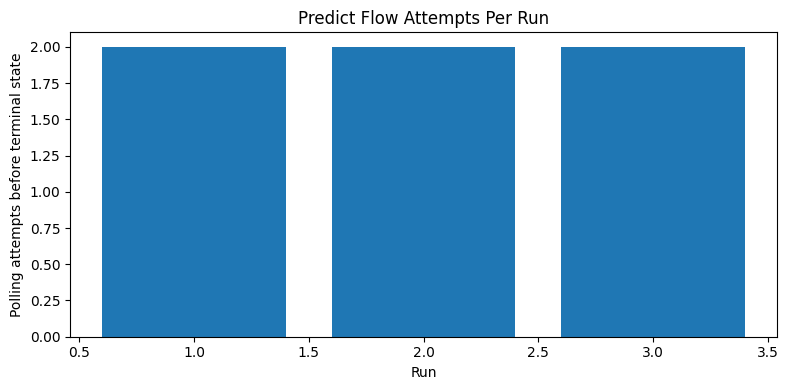

In [27]:
# Optional: run multiple times and compare durations
runs = []
N = 3
for i in range(N):
    run_result = run_predict_flow()
    runs.append(run_result)
    print(f"Run {i + 1}/{N}: task_id={run_result.task_id}, final_status={run_result.final_response.get('status')}")

durations = [len(r.poll_history) for r in runs]

plt.figure(figsize=(8, 4))
plt.bar(range(1, N + 1), durations)
plt.title("Predict Flow Attempts Per Run")
plt.xlabel("Run")
plt.ylabel("Polling attempts before terminal state")
plt.tight_layout()
plt.show()